In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#first we read the data 

df = pd.read_csv(r"C:\Users\Asus\Downloads\Indian_Ecommerce_Transactions_6000Rows.csv")
print("Dataset load successfully")
df


Dataset load successfully


,OrderID,OrderDate,CustomerID,ProductID,Category,City,State,Quantity,UnitPrice,Discount,TotalAmount,PaymentMethod
0,1,2023-04-01,1380.0,14987,Sports,Delhi,GJ,4,4592.54,0.25,13777.62,Debit Card
1,2,2024-12-05,1423.0,19168,Grocery,Ahmedabad,MH,1,3834.30,0.03,3719.27,Credit Card
2,3,2023-01-15,1158.0,14770,Clothing,Mumbai,KA,5,1999.52,0.18,8198.03,UPI
3,4,2023-08-13,1719.0,15410,Beauty,Chennai,MH,1,1889.81,0.28,1360.66,Credit Card
4,5,2024-11-25,1443.0,13742,Beauty,Delhi,KA,3,1402.73,NaN,NaN,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5996,2023-11-03,1555.0,19659,Electronics,Mumbai,KA,5,571.39,0.10,2571.26,Cash on Delivery
5996,5997,2024-06-06,1581.0,12015,Sports,Kolkata,MH,1,4695.29,0.27,3427.56,UPI
5997,5998,2023-10-17,NaN,13570,Home,Hyderabad,TS,3,4825.54,0.14,12449.89,UPI
5998,5999,2023-03-24,1822.0,16607,Electronics,Kolkata,MH,3,4296.43,0.17,10698.11,Credit Card


In [4]:
# CHECK DATASET SHAPE

print("Shape of Dataset:", df.shape)

Shape of Dataset: (6000, 12)


In [5]:
# check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        6000 non-null   int64  
 1   OrderDate      6000 non-null   object 
 2   CustomerID     5727 non-null   float64
 3   ProductID      6000 non-null   int64  
 4   Category       6000 non-null   object 
 5   City           6000 non-null   object 
 6   State          6000 non-null   object 
 7   Quantity       6000 non-null   int64  
 8   UnitPrice      6000 non-null   float64
 9   Discount       5706 non-null   float64
 10  TotalAmount    5706 non-null   float64
 11  PaymentMethod  5721 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 562.6+ KB


In [6]:
# it is use to check the number of count , mean ,median, min,max value at time
df.describe()

,OrderID,CustomerID,ProductID,Quantity,UnitPrice,Discount,TotalAmount
count,6000.000000,5727.000000,6000.000000,6000.000000,6000.000000,5706.000000,5706.000000
mean,3000.500000,1503.002445,15069.291000,2.998833,2615.847755,0.150389,6687.952445
std,1732.195139,288.339294,2894.542044,1.420153,1388.443791,0.087015,5162.010827
min,1.000000,1000.000000,10002.000000,1.000000,200.130000,0.000000,155.180000
25%,1500.750000,1256.000000,12581.750000,2.000000,1411.322500,0.070000,2554.817500
50%,3000.500000,1502.000000,15104.500000,3.000000,2617.705000,0.150000,5276.635000
75%,4500.250000,1753.000000,17580.750000,4.000000,3837.457500,0.230000,9757.110000
max,6000.000000,2000.000000,19996.000000,5.000000,4999.760000,0.300000,24466.780000


In [7]:
# now we check is there any null value is there or not
df.isna()

,OrderID,OrderDate,CustomerID,ProductID,Category,City,State,Quantity,UnitPrice,Discount,TotalAmount,PaymentMethod
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,False,False,False,False,False,False,False,False,False,False,False,False
5996,False,False,False,False,False,False,False,False,False,False,False,False
5997,False,False,True,False,False,False,False,False,False,False,False,False
5998,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
# now we sum all the null value 
df.isna().sum()

OrderID            0
OrderDate          0
CustomerID       273
ProductID          0
Category           0
City               0
State              0
Quantity           0
UnitPrice          0
Discount         294
TotalAmount      294
PaymentMethod    279
dtype: int64

In [9]:
# now we check particular column missing value 
print(df['CustomerID'].isna().sum())

273


In [10]:
# fill customer id null value

df['CustomerID'].fillna(-1,inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_16012\4232052723.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustomerID'].fillna(-1,inplace=True)


In [11]:
print(df['CustomerID'].isna().sum())

    #her u see we handle the missing value by -1 because we deal with

0


# discount column

In [12]:
print("check missng value:")
print(df['Discount'].isna().sum())

check missng value:
294


In [13]:
#Generally discount data skewed hota hai,
# isliye Median safest option hota hai.

median_value=df['Discount'].median()
df['Discount'].fillna(median_value, inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_16012\2027083925.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Discount'].fillna(median_value, inplace=True)


In [14]:
print(df['Discount'].isna().sum())

0


# TotalAmount

In [15]:
print(df['TotalAmount'].isna().sum())

294


In [45]:
# TotalAmount = Quantity × UnitPrice × (1 - Discount)
# Recalculate only where TotalAmounnt is Null
# TotalAmount is a derived feature calculated from Quantity, UnitPrice, and Discount.
#Therefore, missing values were imputed using the business formula instead of statistical methods.

In [16]:
# Recalculate only where TotalAmount is null
df.loc[df['TotalAmount'].isnull(), 'TotalAmount'] = (
    df['Quantity'] *
    df['UnitPrice'] *
    (1 - df['Discount'])
)

print("\nTotalAmount Null Values After Filling:")
print(df['TotalAmount'].isnull().sum())


TotalAmount Null Values After Filling:
0


In [46]:
df.isna().sum()

OrderID            0
OrderDate          0
CustomerID         0
ProductID          0
Category           0
City               0
State              0
Quantity           0
UnitPrice          0
Discount           0
TotalAmount        0
PaymentMethod    279
dtype: int64

## paymentMethod

In [17]:
print(df["PaymentMethod"].isna().sum())

279


In [18]:
print("most frequent payment method")
print(df["PaymentMethod"].mode())

most frequent payment method
0    Cash on Delivery
Name: PaymentMethod, dtype: object


In [51]:
mode_value=df['PaymentMethod'].mode()[0]
df['PaymentMethod'].fillna(mode_value,inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_4980\3681596719.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PaymentMethod'].fillna(mode_value,inplace=True)


In [19]:
print("\nPaymentMethod null value after filling")
print(df['PaymentMethod'].isnull().sum())


PaymentMethod null value after filling
279


In [20]:
df.isna().sum()

OrderID            0
OrderDate          0
CustomerID         0
ProductID          0
Category           0
City               0
State              0
Quantity           0
UnitPrice          0
Discount           0
TotalAmount        0
PaymentMethod    279
dtype: int64

In [56]:
# here we clear all missing value bu means median mode and sum of all

In [21]:
print(df)

      OrderID   OrderDate  CustomerID  ProductID     Category       City  \
0           1  2023-04-01      1380.0      14987       Sports      Delhi   
1           2  2024-12-05      1423.0      19168      Grocery  Ahmedabad   
2           3  2023-01-15      1158.0      14770     Clothing     Mumbai   
3           4  2023-08-13      1719.0      15410       Beauty    Chennai   
4           5  2024-11-25      1443.0      13742       Beauty      Delhi   
...       ...         ...         ...        ...          ...        ...   
5995     5996  2023-11-03      1555.0      19659  Electronics     Mumbai   
5996     5997  2024-06-06      1581.0      12015       Sports    Kolkata   
5997     5998  2023-10-17        -1.0      13570         Home  Hyderabad   
5998     5999  2023-03-24      1822.0      16607  Electronics    Kolkata   
5999     6000  2024-07-12      1080.0      19135      Grocery       Pune   

     State  Quantity  UnitPrice  Discount  TotalAmount     PaymentMethod  
0       GJ  

# Visualisation 

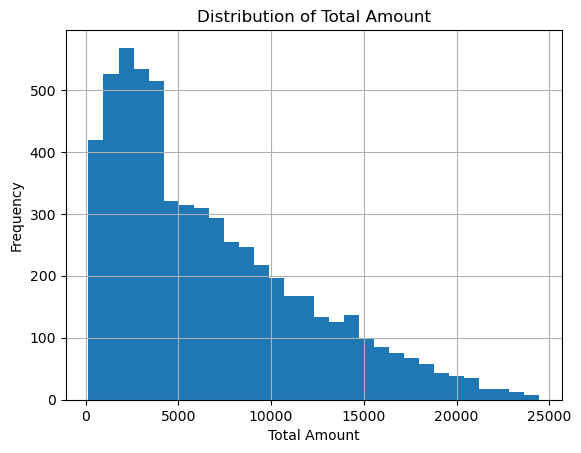

In [22]:
# 2️⃣ HISTOGRAM – Total Amount Distribution
# ==========================================
# 👉 Sales amount ka distribution pattern dekhne ke liye.
plt.figure()
df['TotalAmount'].hist(bins=30)
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

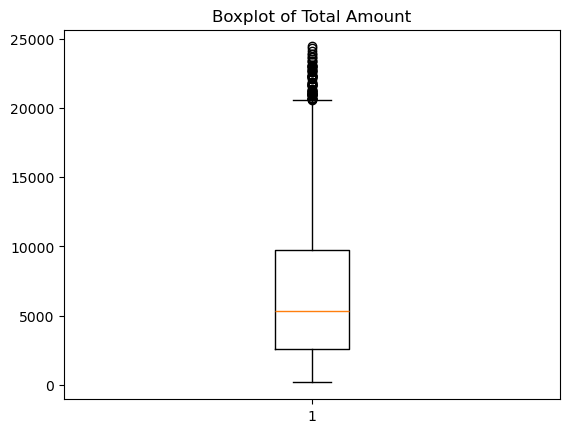

In [23]:
# 3️⃣ BOXPLOT – Outlier Detection (Total Amount)
# ==========================================
# 👉 Outliers aur data spread identify karne ke liye.
plt.figure()
plt.boxplot(df['TotalAmount'])
plt.title("Boxplot of Total Amount")
plt.show()

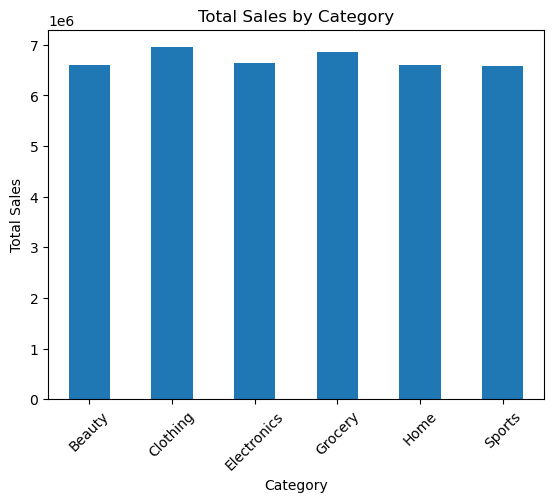

In [24]:
# 4️⃣ BAR CHART – Category Wise Sales
# ==========================================
#👉 Kaunsi category sabse zyada
# revenue generate kar rahi hai ye dekhne ke liye.

plt.figure()
category_sales = df.groupby('Category')['TotalAmount'].sum()
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

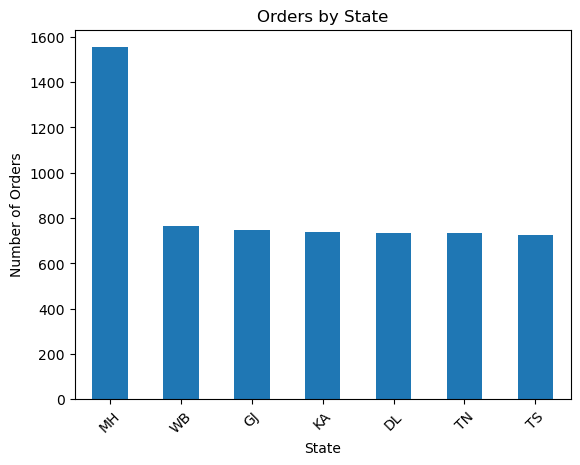

In [25]:
# 5️⃣ BAR CHART – State Wise Orders
# ==========================================
# 👉 Kis state se sabse zyada orders aa rahe hain
# ye analyse karne ke liye.
plt.figure()
state_orders = df['State'].value_counts()
state_orders.plot(kind='bar')
plt.title("Orders by State")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

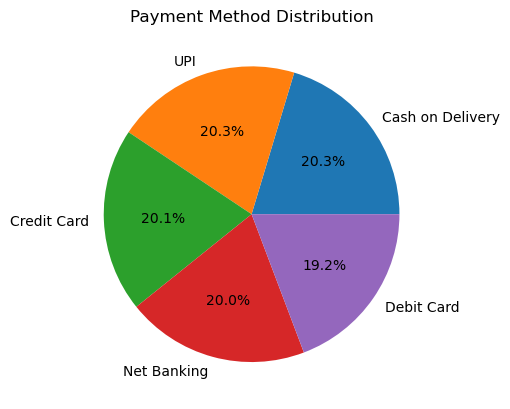

In [26]:
# 6️⃣ PIE CHART – Payment Method Distribution
# ==========================================
#👉 Customers ka preferred payment method percentage me dekhne ke liye.
plt.figure()
payment_counts = df['PaymentMethod'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()


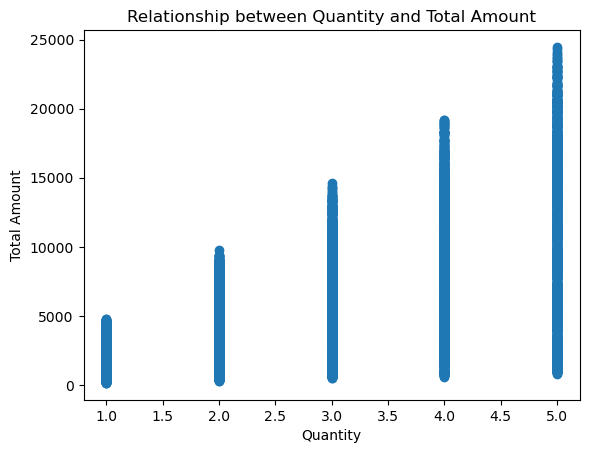

In [27]:
# 7️⃣ SCATTER PLOT – Quantity vs TotalAmount
# ==========================================
# 👉 Quantity aur total amount ke beech relationship samajhne ke liye.
plt.figure()
plt.scatter(df['Quantity'], df['TotalAmount'])
plt.title("Relationship between Quantity and Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()

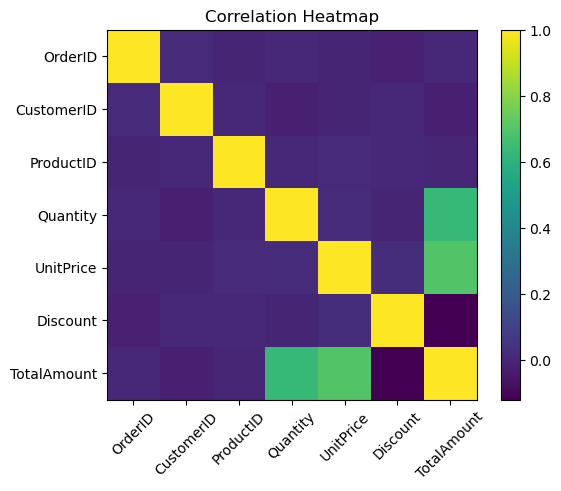

In [28]:
# 9️⃣ CORRELATION HEATMAP (Numeric Columns)
# ==========================================
# 👉 Numeric features ke beech correlation strength analyse karne ke liye.
plt.figure()
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

In [29]:
print("Visualization Completed Successfully ✅")

Visualization Completed Successfully ✅


In [30]:
df.to_csv("cleaned_e_commerce_data.csv")

In [31]:
df.to_excel("adityadata.xlsx")